## **Medical Image Processing**
### Liver Steatosis Challenge
Group components: Milena Finazzi (s346592), Maria Chiara Ierovante (s332089), Lucia Marino (s337688), Martina Petrone (s333821)


In [ ]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Show versioning of deep learning libraries
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

2.9.0+cu126 True


In [ ]:
!pip install torchstain

In [ ]:

import torch
import torchstain
import cv2
import numpy as np
import os
from tqdm import tqdm
from PIL import Image
import random
import matplotlib.pyplot as plt

print(f"✅ TorchStain version: {torchstain.__version__ if hasattr(torchstain, '__version__') else 'unknown'}")
print(f"✅ PyTorch version: {torch.__version__}")

✅ TorchStain version: 1.3.0
✅ PyTorch version: 2.9.0+cu126


In [ ]:
# Define paths
current_dir = "/content/drive/MyDrive/Colab Notebooks/Progetto" # Change the path with your main folder
baseline_dir = os.path.join(current_dir, "prep", "prep7_Macenko")
data_dir = os.path.join(current_dir,"dataset") # Change the path with the one that leads to the given data
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
checkpoint_dir = os.path.join(baseline_dir, "checkpoints_prep7_Macenko_soglia7")
os.makedirs(checkpoint_dir, exist_ok=True)
image_train_dir = os.path.join(train_dir, "image")
manual_train_dir = os.path.join(train_dir, "manual")
manual_py_train_dir = os.path.join(train_dir, "manual_py")
image_val_dir = os.path.join(val_dir, "image")
manual_val_dir = os.path.join(val_dir, "manual")
manual_py_val_dir = os.path.join(val_dir, "manual_py")
output_masks_dir = os.path.join(baseline_dir,"results_prep7_Macenko") # path for saving output masks

# Directory output
output_train_dir = os.path.join(baseline_dir, "preprocessed_macenko7", "train", "image")
output_val_dir = os.path.join(baseline_dir, "preprocessed_macenko7", "val", "image")

os.makedirs(output_train_dir, exist_ok=True)
os.makedirs(output_val_dir, exist_ok=True)

🎯 Target impostato manualmente: 1001001_16.png


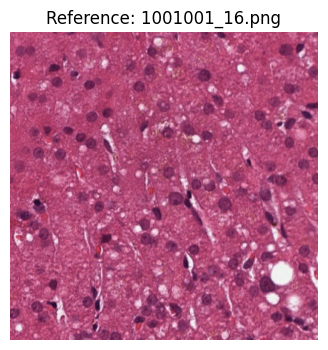

Calcolo vettori Stain del target...

--- Elaborazione TRAIN Set ---


Normalizing TRAIN: 100%|██████████| 408/408 [01:07<00:00,  6.09it/s]



--- Elaborazione VAL Set ---


Normalizing VAL: 100%|██████████| 51/51 [00:08<00:00,  5.81it/s]


✅ Preprocessing Completato! Immagini salvate.


In [ ]:
import numpy as np
from PIL import Image
import os
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNZIONI MACENKO (Numpy/PIL Implementation from normalization.py)
# ==========================================

def get_stain_vectors(I, beta=0.15, alpha=1):
    """
    Get the stain matrix (2x3) using Macenko's method.
    """
    # Reshape to (H*W, 3)
    I = I.reshape((-1, 3))

    # Calculate Optical Density (OD)
    # OD = -log10((I+1)/Io) -> we assume Io=255 for standard RGB 8-bit images
    # Add 1 to avoid log(0)
    OD = -np.log10((I.astype(np.float64) + 1) / 255.0)

    # Remove data with too little absorbance (transparent pixels)
    ODhat = OD[np.all(OD > beta, axis=1)]
    
    if len(ODhat) < 10:
        # Fallback if almost empty
        return np.eye(2), np.zeros(2)

    # PCA via SVD
    # Covariance matrix
    # Normalize features
    _, V = np.linalg.eigh(np.cov(ODhat, rowvar=False))

    # Project onto the regular plane
    # V[:, 1:] corresponds to the eigenvectors corresponding to the two largest eigenvalues
    # Note: numpy eigh returns eigenvalues in ascending order, so take last 2.
    Vec = V[:, 1:3] # Shape (3, 2). These are the directions.

    # Project data onto the plane
    That = np.dot(ODhat, Vec)

    # Find the min and max vectors (robustly)
    phi = np.arctan2(That[:, 1], That[:, 0])
    
    minPhi = np.percentile(phi, alpha)
    maxPhi = np.percentile(phi, 100 - alpha)

    vMin = np.dot(Vec, np.array([np.cos(minPhi), np.sin(minPhi)]))
    vMax = np.dot(Vec, np.array([np.cos(maxPhi), np.sin(maxPhi)]))

    # Heuristic: make sure the first vector is H (more pink/red) and second is E (more blue/purple)
    # Let's just return them sorted by the angle for now to ensure consistency.

    if vMin[0] > vMax[0]:
        HE = np.array([vMin, vMax])
    else:
        HE = np.array([vMax, vMin])
    
    # Rows are stain vectors. Shape (2, 3)
    return HE.T

def get_concentrations(I, stain_matrix, beta=0.15):
    """
    Get concentrations given an image and stain matrix.
    """
    I = I.reshape((-1, 3))
    OD = -np.log10((I.astype(np.float64) + 1) / 255.0)
    
    # We solve OD = C * S.  C is (N, 2), S is (2, 3).
    # C = OD * pinv(S)
    
    C = np.dot(OD, np.linalg.pinv(stain_matrix.T)) 
    
    return C

def apply_macenko_norm(source_img, target_stats, beta=0.15, alpha=1, Io=255):
    """
    Applica la normalizzazione ad una immagine sorgente usando le statistiche del target.
    target_stats: tupla (target_stain_matrix, target_max_C)
    """
    target_stain_matrix, target_max_C = target_stats
    h, w, c = source_img.shape

    # 1. Get source stain matrix
    source_stain_matrix = get_stain_vectors(source_img, beta, alpha)
    
    # 2. Extract source concentrations
    source_concentrations = get_concentrations(source_img, source_stain_matrix, beta)
    
    # 3. Normalize concentrations
    source_max_C = np.percentile(source_concentrations, 99, axis=0)
    
    # Avoid div by zero
    source_max_C[source_max_C == 0] = 1e-5
    
    # Rescale concentrations to match target range
    C_norm = source_concentrations * (target_max_C / source_max_C)
    
    # 4. Reconstruct image using TARGET stain matrix
    OD_norm = np.dot(C_norm, target_stain_matrix.T)
    
    # Back to RGB
    I_norm = Io * np.exp(-OD_norm)
    I_norm = np.clip(I_norm, 0, 255).astype(np.uint8)
    I_norm = I_norm.reshape((h, w, c))

    return I_norm

# ==========================================
# 2. CONFIGURAZIONE PATH E TARGET FISSO
# ==========================================

# Path di base
current_dir = "/content/drive/MyDrive/Colab Notebooks/Progetto"
data_dir = os.path.join(current_dir, "dataset")
train_dir = os.path.join(data_dir, "train", "image")
val_dir = os.path.join(data_dir, "val", "image")

# Cartelle di output
output_base_dir = os.path.join(current_dir, "prep", "prep7_Macenko", "preprocessed_images")
output_train_dir = os.path.join(output_base_dir, "train", "image")
output_val_dir = os.path.join(output_base_dir, "val", "image")

os.makedirs(output_train_dir, exist_ok=True)
os.makedirs(output_val_dir, exist_ok=True)

# --- DEFINIZIONE TARGET DIRETTA ---
target_filename = "1001001_16.png"  # <--- TARGET HARDCODED QUI
target_path = os.path.join(train_dir, target_filename)

print(f"🎯 Target impostato manualmente: {target_filename}")

if not os.path.exists(target_path):
    raise FileNotFoundError(f"❌ ERRORE: Il file target {target_path} non esiste!")

# Caricamento Target e Visualizzazione
target_np = np.array(Image.open(target_path).convert('RGB'))

plt.figure(figsize=(4, 4))
plt.imshow(target_np)
plt.title(f"Reference: {target_filename}")
plt.axis('off')
plt.show()

# --- PRE-CALCOLO STATISTICHE TARGET ---
print("Calcolo vettori Stain del target...")
beta_val = 0.15
alpha_val = 1.0

# 1. Matrice Stain Target
target_stain_matrix = get_stain_vectors(target_np, beta=beta_val, alpha=alpha_val)
# 2. Concentrazioni Target
target_concentrations = get_concentrations(target_np, target_stain_matrix, beta=beta_val)
# 3. Max Concentrazioni Target (99 percentile)
target_max_C = np.percentile(target_concentrations, 99, axis=0)

# Pacchetto statistiche da riutilizzare nel loop
target_stats = (target_stain_matrix, target_max_C)

# ==========================================
# 3. ESECUZIONE NORMALIZZAZIONE (Train & Val)
# ==========================================

datasets_to_process = [
    ("TRAIN", train_dir, output_train_dir),
    ("VAL", val_dir, output_val_dir)
]

for set_name, input_folder, output_folder in datasets_to_process:
    print(f"\n--- Elaborazione {set_name} Set ---")
    files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith(('.png', '.jpg'))])

    for f in tqdm(files, desc=f"Normalizing {set_name}"):
        src_path = os.path.join(input_folder, f)
        dst_path = os.path.join(output_folder, f)

        try:
            # 1. Carica originale
            source_img = np.array(Image.open(src_path).convert('RGB'))

            # 2. Applica Macenko con statistiche del target specifico
            normalized_img_np = apply_macenko_norm(source_img, target_stats, beta=beta_val, alpha=alpha_val)

            # 3. Salva
            Image.fromarray(normalized_img_np).save(dst_path)

        except Exception as e:
            print(f"⚠️ Errore su {f}: {e}. Copia dell'originale in corso...")
            shutil.copy(src_path, dst_path)

print("\n✅ Preprocessing Completato! Immagini salvate.")

File selezionato [233]: 1004122_72.png
Originale: /content/drive/MyDrive/Colab Notebooks/Progetto/dataset/train/image/1004122_72.png
Normalizzata: /content/drive/MyDrive/Colab Notebooks/Progetto/prep/prep7_Macenko/preprocessed_images/train/image/1004122_72.png


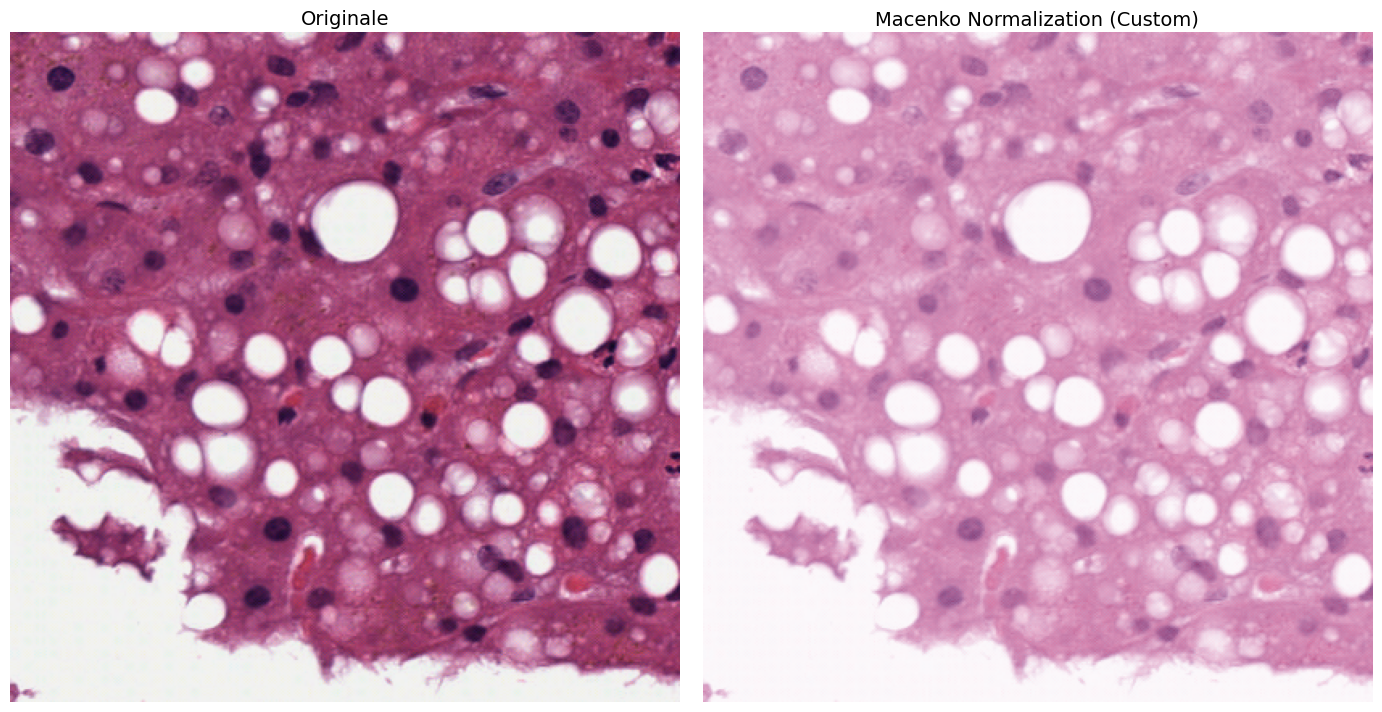

In [ ]:
# %% [code]
# 9. Visualizzazione Confronto: Originale vs Normalizzata
import random
import cv2
import matplotlib.pyplot as plt
import os

# 1. Filtra solo i file immagini validi nella cartella di output
valid_extensions = ('.png', '.jpg', '.jpeg')
files = sorted([f for f in os.listdir(output_train_dir) if f.lower().endswith(valid_extensions)])

if len(files) == 0:
    print("❌ Errore: Nessuna immagine trovata nella cartella di output!")
else:
    # Seleziona un indice casuale per vedere esempi diversi, oppure fissa un numero (es. 400)
    # idx = 400 if len(files) > 400 else 0
    idx = random.randint(0, len(files) - 1)

    sample_file = files[idx]

    # Costruisci i percorsi completi
    path_orig = os.path.join(image_train_dir, sample_file)
    path_norm = os.path.join(output_train_dir, sample_file)

    print(f"File selezionato [{idx}]: {sample_file}")
    print(f"Originale: {path_orig}")
    print(f"Normalizzata: {path_norm}")

    # Carica le immagini
    img_orig = cv2.imread(path_orig)
    img_norm = cv2.imread(path_norm)

    # Verifica caricamento
    if img_orig is None:
        print(f"❌ ERRORE: Impossibile caricare l'originale: {path_orig}")
    elif img_norm is None:
        print(f"❌ ERRORE: Impossibile caricare la normalizzata: {path_norm}")
    else:
        # Converti BGR -> RGB per Matplotlib
        orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        norm_rgb = cv2.cvtColor(img_norm, cv2.COLOR_BGR2RGB)

        # Visualizza
        fig, ax = plt.subplots(1, 2, figsize=(14, 7))

        ax[0].imshow(orig_rgb)
        ax[0].set_title("Originale", fontsize=14)
        ax[0].axis('off')

        ax[1].imshow(norm_rgb)
        ax[1].set_title("Macenko Normalization (Custom)", fontsize=14)
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()

**U-NET model**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """Applies two consecutive conv-batchnorm-relu layers"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self,
                 in_channels=3,
                 out_channels=1,
                 init_filters=64,
                 depth=4,
                 bilinear=True):
        super(UNet, self).__init__()
        self.depth = depth
        self.down_layers = nn.ModuleList()
        self.up_layers = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        # Encoder
        filters = init_filters
        for d in range(depth):
            conv = DoubleConv(in_channels, filters)
            self.down_layers.append(conv)
            in_channels = filters
            filters *= 2

        # Bottleneck
        self.bottleneck = DoubleConv(in_channels, filters)

        # Decoder
        for d in range(depth):
            filters //= 2
            if bilinear:
                up = nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
                    nn.Conv2d(filters * 2, filters, kernel_size=1)
                )
            else:
                up = nn.ConvTranspose2d(filters * 2, filters, kernel_size=2, stride=2)
            self.up_layers.append(nn.ModuleDict({
                'up': up,
                'conv': DoubleConv(filters * 2, filters)
            }))

        # Output layer
        self.out_conv = nn.Conv2d(init_filters, out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.down_layers:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for i in range(self.depth):
            skip = skip_connections[-(i+1)]
            up = self.up_layers[i]['up'](x)
            if up.size() != skip.size():
                # Resize in case of odd size mismatch
                up = F.interpolate(up, size=skip.shape[2:])
            x = torch.cat([skip, up], dim=1)
            x = self.up_layers[i]['conv'](x)

        return self.out_conv(x)

In [ ]:
model = UNet(in_channels=3, out_channels=1, init_filters=64, depth=4)
x = torch.randn(1, 3, 416, 416)  # example input
out = model(x)
print(out.shape)

torch.Size([1, 1, 416, 416])


In [ ]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=1, out_channels=1, init_filters=64, depth=4)
model.to(device)

summary(model, input_size=(1, 416, 416))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 416, 416]             640
       BatchNorm2d-2         [-1, 64, 416, 416]             128
              ReLU-3         [-1, 64, 416, 416]               0
            Conv2d-4         [-1, 64, 416, 416]          36,928
       BatchNorm2d-5         [-1, 64, 416, 416]             128
              ReLU-6         [-1, 64, 416, 416]               0
        DoubleConv-7         [-1, 64, 416, 416]               0
         MaxPool2d-8         [-1, 64, 208, 208]               0
            Conv2d-9        [-1, 128, 208, 208]          73,856
      BatchNorm2d-10        [-1, 128, 208, 208]             256
             ReLU-11        [-1, 128, 208, 208]               0
           Conv2d-12        [-1, 128, 208, 208]         147,584
      BatchNorm2d-13        [-1, 128, 208, 208]             256
             ReLU-14        [-1, 128, 2

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        # inputs: raw logits -> apply sigmoid
        inputs = torch.sigmoid(inputs)

        # Flatten
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            inputs.sum() + targets.sum() + self.smooth
        )

        return 1 - dice  # Dice Loss

In [ ]:
# Network architecture
input_size = (416,416)
in_channels = 3    # 1 for grayscale, 3 for RGB images
out_channels = 1   # 1 for binary segmentation, N for multiclass segmentation
init_filters = 64
depth = 4

# Training hyperparameters
criterion = DiceLoss()  # loss function
n_epochs = 50
batch_size = 8 # between 2 and 8
learning_rate = 1e-4
checkpoint_freq = 1  # save every checkpoint

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

In [ ]:
# Save config file with the user-defined parameters of the current run
import json

params = {
    "input_size": input_size,
    "in_channels": in_channels,
    "out_channels": out_channels,
    "init_filters": init_filters,
    "depth": depth,
    "n_epochs": n_epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "checkpoint_freq": checkpoint_freq,
}

params_path = os.path.join(checkpoint_dir, 'training_params.json')
with open(params_path, 'w') as f:
    json.dump(params, f, indent=4)
print(f"Training parameters saved to {params_path}")

Training parameters saved to /content/drive/MyDrive/Colab Notebooks/Progetto/prep/prep7_Macenko/checkpoints_prep7_Macenko_soglia7/training_params.json


In [ ]:
def dice_score(pred, target, threshold=0.5):
    """
    Calculate BOTH Dice scores:
    1. DSC_standard: IDENTICO alla tua funzione originale (con smooth, mai NaN)
    2. DSC_strict: Follows contest rules (NaN when both masks empty)

    Args:
        pred: [1, C, H, W] or [C, H, W] single image predictions
        target: [1, C, H, W] or [C, H, W] ground truth
        threshold: binarization threshold

    Returns:
        dict with keys: 'dsc_standard', 'dsc_strict'
    """
    # Convert to torch if needed
    if not isinstance(pred, torch.Tensor):
        pred = torch.from_numpy(pred).float()
    if not isinstance(target, torch.Tensor):
        target = torch.from_numpy(target).float()

    # Move to same device
    device = pred.device
    target = target.to(device)

    # Apply sigmoid if needed (check if logits)
    if pred.min() < 0 or pred.max() > 1:
        pred = torch.sigmoid(pred)

    # Binarize
    pred = (pred > threshold).float()

    # Calculate sums
    intersection = (pred * target).sum()
    pred_sum = pred.sum()
    target_sum = target.sum()

    # ========================================
    # DSC STANDARD (IDENTICO alla tua funzione originale)
    # ========================================
    smooth = 1e-5
    union = pred_sum + target_sum
    dsc_standard = (2. * intersection + smooth) / (union + smooth)
    dsc_standard = dsc_standard.item()

    # ========================================
    # DSC STRICT (regole contest, con NaN)
    # ========================================
    # CASO 1: Entrambe nere → NaN (escluso da media)
    if target_sum == 0 and pred_sum == 0:
        dsc_strict = float('nan')

    # CASO 2: GT nera, pred ha pixel → Dice = 0 (falsi positivi)
    elif target_sum == 0 and pred_sum > 0:
        dsc_strict = 0.0

    # CASO 3: Calcolo normale (SENZA smooth)
    else:
        dsc_strict = (2. * intersection) / (pred_sum + target_sum)
        dsc_strict = dsc_strict.item()

    return {
        'dsc_standard': dsc_standard,  # IDENTICO alla tua funzione originale
        'dsc_strict': dsc_strict        # Può essere NaN, senza smooth
    }


# ========================================
# VERSIONE BATCH (per validation loop)
# ========================================
def dice_score_batch(pred, target, threshold=0.5):
    """
    Calculate both DSC metrics for a batch of images.

    Args:
        pred: [B, C, H, W] batch predictions
        target: [B, C, H, W] batch ground truth
        threshold: binarization threshold

    Returns:
        dict with keys: 'dsc_standard', 'dsc_strict', 'n_valid', 'n_empty'
    """
    batch_size = pred.shape[0]

    dsc_standard_sum = 0.0
    dsc_strict_values = []

    for i in range(batch_size):
        scores = dice_score(pred[i:i+1], target[i:i+1], threshold)

        dsc_standard_sum += scores['dsc_standard']
        dsc_strict_values.append(scores['dsc_strict'])

    # Media standard (tutti i valori)
    dsc_standard_mean = dsc_standard_sum / batch_size

    # Media strict (escludi NaN)
    dsc_strict_values = np.array(dsc_strict_values)
    dsc_strict_mean = np.nanmean(dsc_strict_values)  # Ignora NaN

    return {
        'dsc_standard': dsc_standard_mean,
        'dsc_strict': dsc_strict_mean,
        'n_valid': int(np.sum(~np.isnan(dsc_strict_values))),  # Quante immagini con contenuto
        'n_empty': int(np.sum(np.isnan(dsc_strict_values)))    # Quante vuote (NaN)
    }

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

train_img_dir = output_train_dir
val_img_dir = output_val_dir
train_mask_dir = manual_py_train_dir
val_mask_dir = manual_py_val_dir

class IMCDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_list = sorted(os.listdir(image_dir))
        self.mask_list = sorted(os.listdir(mask_dir))
        assert len(self.image_list) == len(self.mask_list), "Number of images and masks do not match"

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_list[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_list[idx])
        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')
        img_name = self.image_list[idx]

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Convert mask to binary float tensor (0 or 1)
        mask = (mask > 0).float()

        return image, mask, img_name


# Transformations applied to both images and masks
transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),
])

# Initialize datasets
train_dataset = IMCDataset(train_img_dir, train_mask_dir, transform=transform)
val_dataset = IMCDataset(val_img_dir, val_mask_dir, transform=transform)

# Initialize dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Model initialization
model = UNet(in_channels, out_channels, init_filters, depth).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-5  # L2 regularization per ridurre overfitting
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',          # vogliamo massimizzare DSC
    factor=0.5,          # dimezza LR quando si blocca
    patience=15,         # aspetta 15 epoche senza miglioramento
    min_lr=1e-6,         # LR minimo
    threshold=0.001      # miglioramento minimo considerato significativo
)

In [ ]:
# ===== AUTOMATIC CHECKPOINT RESUME =====
import glob
import os

def find_latest_checkpoint(checkpoint_dir):
    """Find the most recent checkpoint"""
    checkpoints = glob.glob(os.path.join(checkpoint_dir, 'model_epoch_*.pth'))
    if len(checkpoints) == 0:
        return None
    return max(checkpoints, key=os.path.getctime)

def load_checkpoint(checkpoint_path, model, optimizer):
    """Load model and optimizer state from checkpoint"""
    print(f"\n{'='*70}")
    print(f"LOADING CHECKPOINT")
    print(f"{'='*70}")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_dice = checkpoint.get('val_dice', 0.0)

    print(f" Checkpoint loaded: {os.path.basename(checkpoint_path)}")
    print(f"   Resuming from epoch: {start_epoch}")
    print(f"   Last train loss: {checkpoint.get('train_loss', 'N/A'):.4f}")
    print(f"   Last val loss: {checkpoint.get('val_loss', 'N/A'):.4f}")
    print(f"   Best val DSC: {best_val_dice:.4f}")
    print(f"{'='*70}\n")

    return start_epoch, best_val_dice

# Check for existing checkpoint
latest_ckpt = find_latest_checkpoint(checkpoint_dir)

if latest_ckpt is not None:
    print(f" Found existing checkpoint: {os.path.basename(latest_ckpt)}")

    # AUTO-RESUME
    start_epoch, best_val_dice = load_checkpoint(latest_ckpt, model, optimizer)
    print(f" Automatically resuming training from epoch {start_epoch}\n")
else:
    print(" No checkpoint found. Starting fresh training.\n")
    start_epoch = 0
    best_val_dice = 0.0


 No checkpoint found. Starting fresh training.



In [ ]:
print(f"Train set size: {len(train_loader.dataset)} images")
print(f"Validation set size: {len(val_loader.dataset)} images")
print(f"Batch size: {train_loader.batch_size}")
print(f"Training batches per epoch: {len(train_loader)}")
print(f"Validation batches per epoch: {len(val_loader)}")

Train set size: 408 images
Validation set size: 51 images
Batch size: 8
Training batches per epoch: 51
Validation batches per epoch: 7


In [ ]:
import cv2
from sklearn.metrics import jaccard_score
import numpy as np
import torch
import os
from tqdm import tqdm

# --- CONFIGURAZIONE SOGLIE ---
thresholds = np.arange(0.1, 0.95, 0.05)

# Inizializzazione tracking miglior modello
best_val_dice_strict = 0.0
start_epoch = 0

# NUOVO: Per early stopping
patience_counter = 0
early_stopping_patience = 30  # ferma se non migliora per 30 epoche

for epoch in range(start_epoch, n_epochs):
    # --- TRAINING ---
    model.train()
    train_loss = 0.0
    train_dsc_batch = 0.0
    train_dsc_per_image = 0.0

    for images, masks, names in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} - Training"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, masks)
        loss.backward()

        # NUOVO: Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        # Calcola DSC batch-based e per-image durante training
        with torch.no_grad():
            dsc_batch = dice_score(outputs, masks, threshold=0.5)['dsc_standard']
            train_dsc_batch += dsc_batch * images.size(0)

            batch_dsc_per_image = []
            for i in range(images.size(0)):
                single_output = outputs[i:i+1]
                single_mask = masks[i:i+1]
                dsc_i = dice_score(single_output, single_mask, threshold=0.5)['dsc_standard']
                batch_dsc_per_image.append(dsc_i)
            train_dsc_per_image += sum(batch_dsc_per_image)

    train_loss /= len(train_loader.dataset)
    train_dsc_batch /= len(train_loader.dataset)
    train_dsc_per_image /= len(train_loader.dataset)

    # NUOVO: Current learning rate
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1} Train Loss: {train_loss:.4f}")
    print(f"  Train DSC (batch-based): {train_dsc_batch:.4f}")
    print(f"  Train DSC (per-image): {train_dsc_per_image:.4f}")
    print(f"  Current LR: {current_lr:.6f}")

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0

    val_dice_standard = {round(t, 2): [] for t in thresholds}
    val_dice_strict = {round(t, 2): [] for t in thresholds}

    val_dsc_batch_standard = {round(t, 2): [] for t in thresholds}
    val_dsc_batch_strict = {round(t, 2): [] for t in thresholds}

    all_probs = []
    all_masks = []
    all_names = []

    with torch.no_grad():
        for images, masks, names in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)

            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)

            # DSC batch-based
            for t in thresholds:
                dice_batch = dice_score(outputs, masks, threshold=t)
                val_dsc_batch_standard[round(t, 2)].append(dice_batch['dsc_standard'])
                val_dsc_batch_strict[round(t, 2)].append(dice_batch['dsc_strict'])

            # DSC per-image
            batch_size = outputs.shape[0]
            for i in range(batch_size):
                single_output = outputs[i:i+1]
                single_mask = masks[i:i+1]

                for t in thresholds:
                    dice = dice_score(single_output, single_mask, threshold=t)
                    val_dice_standard[round(t, 2)].append(dice['dsc_standard'])
                    val_dice_strict[round(t, 2)].append(dice['dsc_strict'])

            probs = torch.sigmoid(outputs)
            all_probs.append(probs.cpu().numpy())
            all_masks.append(masks.cpu().numpy())
            all_names.extend(names)

    val_loss /= len(val_loader.dataset)

    # Calcola medie
    avg_dices_standard = {t: np.mean(val_dice_standard[t]) for t in val_dice_standard}
    avg_dices_strict = {t: np.nanmean(val_dice_strict[t]) for t in val_dice_strict}

    avg_dices_batch_standard = {t: np.mean(val_dsc_batch_standard[t]) for t in val_dsc_batch_standard}
    avg_dices_batch_strict = {t: np.nanmean(val_dsc_batch_strict[t]) for t in val_dsc_batch_strict}

    # Best threshold per ogni metrica
    best_t_standard = max(avg_dices_standard, key=avg_dices_standard.get)
    best_dice_standard = avg_dices_standard[best_t_standard]

    best_t_strict = max(avg_dices_strict, key=avg_dices_strict.get)
    best_dice_strict = avg_dices_strict[best_t_strict]

    best_t_batch_standard = max(avg_dices_batch_standard, key=avg_dices_batch_standard.get)
    best_dice_batch_standard = avg_dices_batch_standard[best_t_batch_standard]

    best_t_batch_strict = max(avg_dices_batch_strict, key=avg_dices_batch_strict.get)
    best_dice_batch_strict = avg_dices_batch_strict[best_t_batch_strict]

    strict_values = np.array(val_dice_strict[best_t_strict])
    n_valid = int(np.sum(~np.isnan(strict_values)))
    n_empty = int(np.sum(np.isnan(strict_values)))

    y_true = np.concatenate(all_masks).flatten()
    y_probs = np.concatenate(all_probs).flatten()
    y_pred = (y_probs > best_t_strict).astype(np.int64)
    iou_epoch = jaccard_score(y_true.astype(np.int64), y_pred, average='binary')

    print(f"Epoch {epoch+1} Val Loss: {val_loss:.4f}")
    print(f"  DSC Per-Image Standard: {best_dice_standard:.4f} @ threshold {best_t_standard:.2f}")
    print(f"  DSC Per-Image Strict: {best_dice_strict:.4f} @ threshold {best_t_strict:.2f}")
    print(f"  DSC Batch-Based Standard: {best_dice_batch_standard:.4f} @ threshold {best_t_batch_standard:.2f}")
    print(f"  DSC Batch-Based Strict: {best_dice_batch_strict:.4f} @ threshold {best_t_batch_strict:.2f}")
    print(f"    Valid images: {n_valid}, Empty images: {n_empty}")
    print(f"    Val IoU: {iou_epoch:.4f}")

    # NUOVO: Update learning rate scheduler
    scheduler.step(best_dice_strict)

    # --- SALVATAGGIO MIGLIOR MODELLO ---
    if best_dice_strict > best_val_dice_strict:
        best_val_dice_strict = best_dice_strict
        patience_counter = 0  # RESET counter
        best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),  # NUOVO: salva scheduler
            'best_threshold_standard': best_t_standard,
            'best_threshold_strict': best_t_strict,
            'best_threshold_batch_standard': best_t_batch_standard,
            'best_threshold_batch_strict': best_t_batch_strict,
            'val_dice_standard': best_dice_standard,
            'val_dice_strict': best_dice_strict,
            'val_dice_batch_standard': best_dice_batch_standard,
            'val_dice_batch_strict': best_dice_batch_strict,
            'train_dsc_batch': train_dsc_batch,
            'train_dsc_per_image': train_dsc_per_image,
            'n_valid': n_valid,
            'n_empty': n_empty,
            'val_loss': val_loss,
            'train_loss': train_loss,
            'learning_rate': current_lr,  # NUOVO
        }, best_model_path)

        # Salvataggio maschere PNG
        results_dir = os.path.join(checkpoint_dir, 'best_validation_results')
        gt_dir = os.path.join(results_dir, 'ground_truth')
        pred_dir = os.path.join(results_dir, 'predictions')
        os.makedirs(gt_dir, exist_ok=True)
        os.makedirs(pred_dir, exist_ok=True)

        y_true_best = np.concatenate(all_masks)
        y_pred_best = (np.concatenate(all_probs) > best_t_strict).astype(np.uint8)

        for i in range(len(all_names)):
            orig_name = os.path.splitext(all_names[i])[0] + ".png"
            gt_img = (y_true_best[i].squeeze() * 255).astype(np.uint8)
            pred_img = (y_pred_best[i].squeeze() * 255).astype(np.uint8)
            cv2.imwrite(os.path.join(gt_dir, orig_name), gt_img)
            cv2.imwrite(os.path.join(pred_dir, orig_name), pred_img)

        print(f"  *** NUOVO MIGLIOR MODELLO! DSC Strict (per-image): {best_dice_strict:.4f} @ threshold {best_t_strict:.2f} ***")
    else:
        patience_counter += 1  # NUOVO: incrementa counter
        print(f"  No improvement for {patience_counter} epoch(s)")

    # NUOVO: Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\n{'='*70}")
        print(f"EARLY STOPPING! Nessun miglioramento per {early_stopping_patience} epoche")
        print(f"Best DSC Strict: {best_val_dice_strict:.4f}")
        print(f"{'='*70}")
        break

    # --- CHECKPOINT PERIODICO ---
    if (epoch + 1) % checkpoint_freq == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f'model_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_threshold_standard': best_t_standard,
            'best_threshold_strict': best_t_strict,
            'best_threshold_batch_standard': best_t_batch_standard,
            'best_threshold_batch_strict': best_t_batch_strict,
            'val_dice_standard': best_dice_standard,
            'val_dice_strict': best_dice_strict,
            'val_dice_batch_standard': best_dice_batch_standard,
            'val_dice_batch_strict': best_dice_batch_strict,
            'train_dsc_batch': train_dsc_batch,
            'train_dsc_per_image': train_dsc_per_image,
            'n_valid': n_valid,
            'n_empty': n_empty,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'learning_rate': current_lr,
        }, checkpoint_path)
        print(f"  Checkpoint salvato: epoch_{epoch+1}.pth")

    print("-" * 70)

print("\nADDESTRAMENTO COMPLETATO!")
print(f"Miglior Validation DSC Strict (per-image) ottenuto: {best_val_dice_strict:.4f}")

Epoch 1/50 - Training: 100%|██████████| 51/51 [01:16<00:00,  1.50s/it]

Epoch 1 Train Loss: 0.9052
  Train DSC (batch-based): 0.1692
  Train DSC (per-image): 0.1322
  Current LR: 0.000100


Epoch 1 Val Loss: 0.8449
  DSC Per-Image Standard: 0.2220 @ threshold 0.90
  DSC Per-Image Strict: 0.2220 @ threshold 0.90
  DSC Batch-Based Standard: 0.2656 @ threshold 0.90
  DSC Batch-Based Strict: 0.2656 @ threshold 0.90
    Valid images: 51, Empty images: 0
    Val IoU: 0.2481
  *** NUOVO MIGLIOR MODELLO! DSC Strict (per-image): 0.2220 @ threshold 0.90 ***
  Checkpoint salvato: epoch_1.pth
----------------------------------------------------------------------


Epoch 2/50 - Training: 100%|██████████| 51/51 [01:05<00:00,  1.29s/it]

Epoch 2 Train Loss: 0.8741
  Train DSC (batch-based): 0.3010
  Train DSC (per-image): 0.2093
  Current LR: 0.000100


...

Epoch 49 Train Loss: 0.2344
  Train DSC (batch-based): 0.8025
  Train DSC (per-image): 0.7232
  Current LR: 0.000050


Epoch 49 Val Loss: 0.4141
  DSC Per-Image Standard: 0.6590 @ threshold 0.90
  DSC Per-Image Strict: 0.5652 @ threshold 0.90
  DSC Batch-Based Standard: 0.5528 @ threshold 0.90
  DSC Batch-Based Strict: 0.5528 @ threshold 0.90
    Valid images: 40, Empty images: 11
    Val IoU: 0.6852
  No improvement for 9 epoch(s)
  Checkpoint salvato: epoch_49.pth
----------------------------------------------------------------------


Epoch 50/50 - Training: 100%|██████████| 51/51 [01:05<00:00,  1.28s/it]

Epoch 50 Train Loss: 0.2207
  Train DSC (batch-based): 0.8177
  Train DSC (per-image): 0.7415
  Current LR: 0.000050


Epoch 50 Val Loss: 0.4201
  DSC Per-Image Standard: 0.6736 @ threshold 0.25
  DSC Per-Image Strict: 0.5732 @ threshold 0.25
  DSC Batch-Based Standard: 0.5463 @ threshold 0.60
  DSC Batch-Based Strict: 0.5463 @ threshold 0.60
    Valid images: 39, Empty images: 12
    Val IoU: 0.6516
  No improvement for 10 epoch(s)
  Checkpoint salvato: epoch_50.pth
----------------------------------------------------------------------

ADDESTRAMENTO COMPLETATO!
Miglior Validation DSC Strict (per-image) ottenuto: 0.6192
